In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [61]:
print(os.getcwd())
print(os.listdir('.'))

/home/hiteshah/lessons/KAGGLE_HDB_COMPETITION/Data
['sample_sub_reg.csv', 'model.ipynb', 'submission.csv', 'test.csv', 'train.csv']


In [2]:
df = pd.read_csv('train.csv', low_memory=False)  # Replace with your CSV file path

In [3]:
df.head()

,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,...,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,...,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,...,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,...,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,...,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


In [20]:
import pandas as pd

df = pd.read_csv('train.csv')

print(f"Unique streets: {df['street_name'].nunique()}")
print(f"Unique towns: {df['town'].nunique()}")

/tmp/ipykernel_52539/2648621031.py:3: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


Unique streets: 553
Unique towns: 26


In [29]:
# List of columns you want to view
columns_to_view = ['town','flat_type','mid_storey', 'hdb_age', 'floor_area_sqm']

# Display the first 5 rows of these columns
df[columns_to_view].head()


,town,flat_type,mid_storey,hdb_age,floor_area_sqm
0,KALLANG/WHAMPOA,4 ROOM,11,15,90.0
1,BISHAN,5 ROOM,8,34,130.0
2,BUKIT BATOK,EXECUTIVE,14,24,144.0
3,BISHAN,4 ROOM,3,29,103.0
4,YISHUN,4 ROOM,2,34,83.0


In [30]:
cols = ['town', 'flat_type', 'floor_area_sqm', 'hdb_age', 'mid_storey']
print(df[cols].isnull().sum())
print(df[cols].isnull().any())
print(df[cols].isnull().values.any())

# Remove any NaN values

town              0
flat_type         0
floor_area_sqm    0
hdb_age           0
mid_storey        0
dtype: int64
town              False
flat_type         False
floor_area_sqm    False
hdb_age           False
mid_storey        False
dtype: bool
False


In [31]:
df.isna().sum()

id                   0
Tranc_YearMonth      0
town                 0
flat_type            0
block                0
                    ..
sec_sch_name         0
cutoff_point         0
affiliation          0
sec_sch_latitude     0
sec_sch_longitude    0
Length: 77, dtype: int64

In [32]:
features = ['town', 'flat_type', 'floor_area_sqm', 'hdb_age', 'mid_storey']
X = df[features]
y = df['resale_price']

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Define preprocessing for numeric and categorical features
numeric_features = ['floor_area_sqm', 'hdb_age','mid_storey']
categorical_features = ['town', 'flat_type']

# Numeric pipeline: impute missing values with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values with most frequent, then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Create pipeline with preprocessing and model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])

# Split data into train/test sets and train the pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipeline.fit(X_train, y_train)

# Make predictions and calculate Mean Squared Error
preds = pipeline.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 3779920363.64


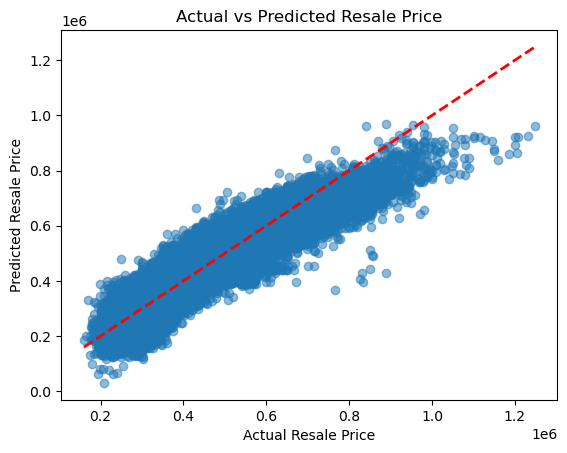

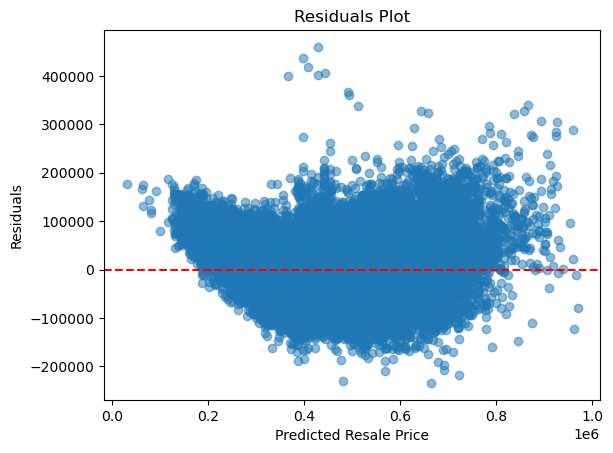

In [34]:
# Plot actual vs predicted values to check model predictions
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.title('Actual vs Predicted Resale Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.show()

# Optional: Residuals plot
residuals = y_test - preds
plt.scatter(preds, residuals, alpha=0.5)
plt.xlabel('Predicted Resale Price')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

In [35]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

preds_train = pipeline.predict(X_train)
residuals_train = y_train - preds_train
rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
mae_train = mean_absolute_error(y_train, preds_train)

print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}")

Train RMSE: 61658.29
Train MAE: 48111.51


/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


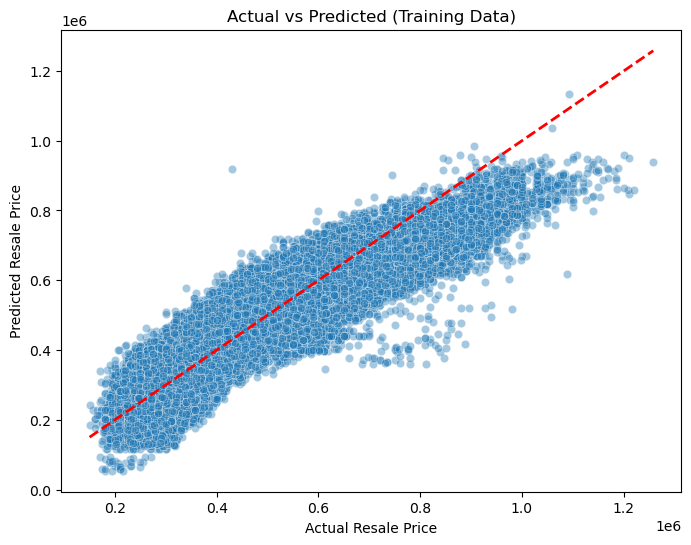

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train, y=preds_train, alpha=0.4)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--', lw=2)
plt.xlabel("Actual Resale Price")
plt.ylabel("Predicted Resale Price")
plt.title("Actual vs Predicted (Training Data)")
plt.show()

/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


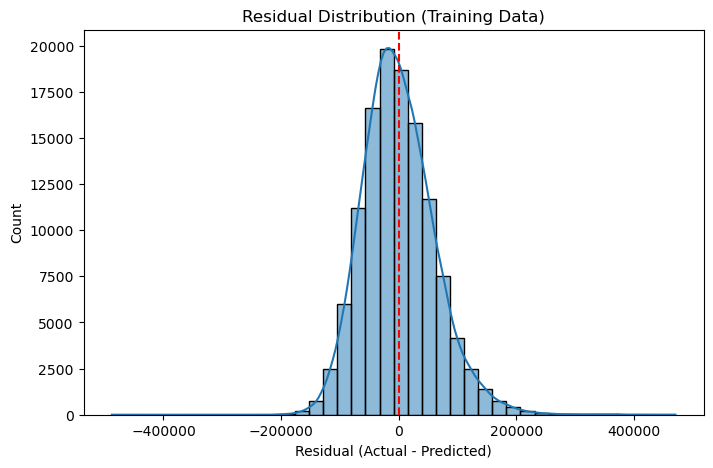

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals_train, kde=True, bins=40)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution (Training Data)")
plt.axvline(0, color='red', linestyle='--')
plt.show()

/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


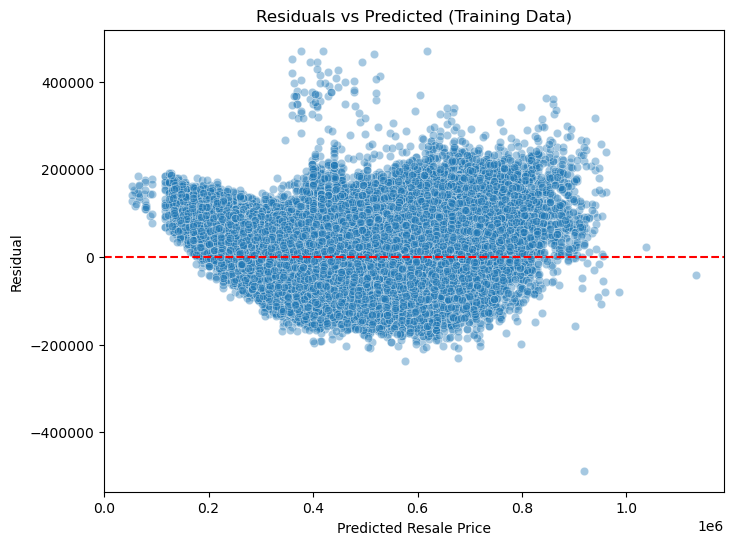

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=preds_train, y=residuals_train, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Resale Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (Training Data)")
plt.show()

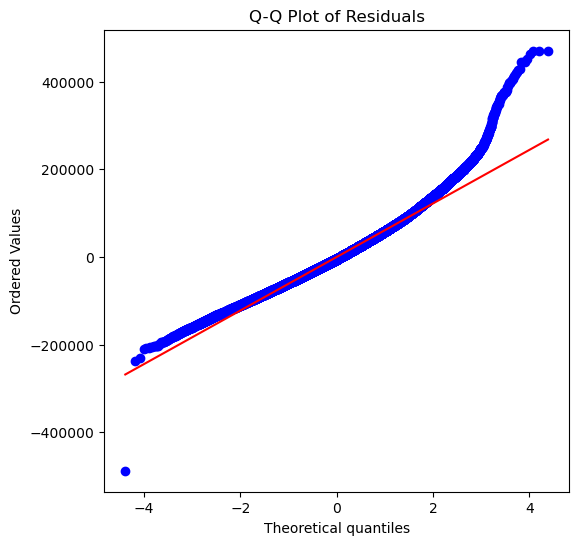

In [39]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuals_train, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/hiteshah/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


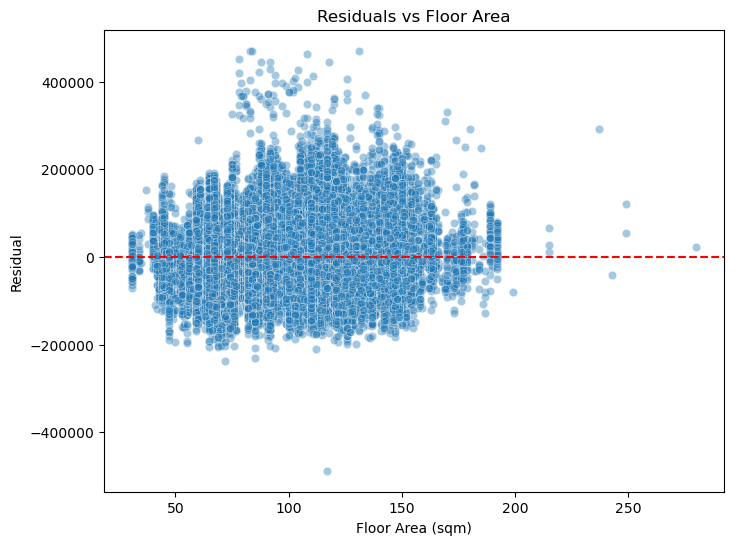

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train['floor_area_sqm'], y=residuals_train, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Residual")
plt.title("Residuals vs Floor Area")
plt.show()

In [42]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, preds, squared=False)
print(f'RMSE: {rmse:.2f}')

RMSE: 61481.06


In [43]:
# Load test data and make predictions
df_test = pd.read_csv('test.csv',low_memory=False)
print(f"Test data rows: {len(df_test)}")
X_test_new = df_test[features]

# Predict using the trained pipeline
test_preds = pipeline.predict(X_test_new)
print(f"Predictions length: {len(test_preds)}")

# Check for missing Ids
missing_ids = df_test['id'].isnull().sum()
print(f"Missing Ids: {missing_ids}")

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': df_test['id'],
    'Predicted': test_preds
})
print(f"Submission rows: {len(submission)}")

import os
version = 1
submission_filename = 'submission.csv'
while os.path.exists(submission_filename):
    submission_filename = f'submission_v{version}.csv'
    version += 1

submission.to_csv(submission_filename, index=False)
print(f"Submission saved as: {submission_filename}")
print(f"Number of predictions: {len(submission)}")

Test data rows: 16737
Predictions length: 16737
Missing Ids: 0
Submission rows: 16737
Submission saved as: submission_v3.csv
Number of predictions: 16737


NameError: name 'test_preds' is not defined